# Groundnut Yield Prediction - Advanced ML Pipeline
### Gujarat Districts | 2000-2021

---

**Objective:** Predict groundnut yield (tonnes/ha) from satellite vegetation indices and climatic variables.

**Pipeline at a glance:**

| Step | Description |
|------|-------------|
| 1 | Data loading & quality check |
| 2 | Exploratory Data Analysis |
| 3 | Feature engineering (7 new features) |
| 4 | Preprocessing & temporal train/test split |
| 5 | 13+ model training with 5-Fold CV |
| 6 | Hyperparameter tuning (XGBoost) |
| 7 | Feature importance & SHAP explainability |
| 8 | Final leaderboard & model comparison |

---

## Section 1 - Libraries

In [10]:
# Run this cell only on Google Colab (uncomment as needed)
# !pip install xgboost lightgbm catboost shap --quiet
print("Skipping install — assumed pre-installed.")

Skipping install — assumed pre-installed.


In [13]:
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import seaborn as sns
from   IPython.display import display

# ── Preprocessing ──────────────────────────────────────────────────────────
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.model_selection  import (train_test_split, KFold,
                                       cross_validate, RandomizedSearchCV)
from sklearn.pipeline         import Pipeline
from sklearn.metrics          import (r2_score, mean_absolute_error,
                                       mean_squared_error)

# ── Models ─────────────────────────────────────────────────────────────────
from sklearn.linear_model  import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble      import (RandomForestRegressor,
                                   GradientBoostingRegressor,
                                   AdaBoostRegressor,
                                   ExtraTreesRegressor,
                                   BaggingRegressor)
from sklearn.svm           import SVR
from sklearn.neighbors     import KNeighborsRegressor
from sklearn.tree          import DecisionTreeRegressor
from xgboost               import XGBRegressor

try:
    from lightgbm  import LGBMRegressor;   HAS_LGBM     = True
except ImportError:
    HAS_LGBM = False;  print("LightGBM not available")

try:
    from catboost  import CatBoostRegressor; HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False; print("CatBoost not available")

try:
    import shap;  HAS_SHAP = True
except ImportError:
    HAS_SHAP = False;  print("SHAP not available")

# ── Plot style ─────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 120, "axes.titlesize": 13,
                     "axes.labelsize": 11, "figure.figsize": (10, 5)})
SEED = 42
print("All libraries loaded.")

SHAP not available
All libraries loaded.


## Section 2 - Data Loading & Quality Check

In [15]:
# Update path as needed — works on Colab and local
DATA_PATH = "/Users/ceedindia/Documents/Python/groundnut yield prediction/Groundnut_Yield_Prediction/Groundnut_Yield_Prediction/Data/Raw_Data.csv"   # <- change if local

df = pd.read_csv(DATA_PATH)
print(f"Shape : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.sample(5)

Shape : (110, 15)
Columns: ['Year', 'District', 'Area_', 'Area', 'Production_', 'Production', 'Yield_(tonnes/ha)', 'NDVI', 'EVI', 'FAPAR', 'GPP', 'LAI', 'Rainfall', 'Temperature', 'SMI']


,Year,District,Area_,Area,Production_,Production,Yield_(tonnes/ha),NDVI,EVI,FAPAR,GPP,LAI,Rainfall,Temperature,SMI
84,2016,Bhavnagar,"1,06,680.00",1.07,"3,56,621.00",35.66,3.34,0.352165,0.236129,2.750900,13.137282,0.588492,64.480657,252.555656,7.433608
93,2018,Amreli,"1,07,221.00",1.07,"75,940.00",7.59,0.71,0.328725,0.200943,2.809569,13.959410,0.611284,61.553972,255.450975,8.357046
2,2000,Rajkot,"3,81,100.00",3.81,"21,600.00",2.16,0.06,0.283901,0.179621,2.730903,12.628797,0.580709,58.791410,259.409928,8.310620
91,2018,Junagadh,"2,30,830.00",2.31,"2,87,593.00",28.76,1.25,0.383636,0.258546,3.178018,17.657363,0.716806,75.491077,247.339524,7.129536
14,2002,Bhavnagar,"2,05,600.00",2.06,"1,77,300.00",17.73,0.86,0.331392,0.217559,2.750900,13.137282,0.588492,64.480657,252.555656,7.433608


In [16]:
# ── Quality report ─────────────────────────────────────────────────────────
report = pd.DataFrame({
    "dtype"      : df.dtypes,
    "null_count" : df.isnull().sum(),
    "null_%"     : (df.isnull().sum() / len(df) * 100).round(2),
    "unique"     : df.nunique(),
})
num = df.select_dtypes("number")
report["min"] = num.min()
report["max"] = num.max()

print(f"Missing values : {df.isnull().sum().sum()}")
print(f"Duplicate rows : {df.duplicated().sum()}")
display(report)

Missing values : 0
Duplicate rows : 0


,dtype,null_count,null_%,unique,min,max
Year,int64,0,0.0,22,2000.000000,2021.000000
District,object,0,0.0,5,NaN,NaN
Area_,object,0,0.0,109,NaN,NaN
Area,float64,0,0.0,85,0.640000,4.580000
Production_,object,0,0.0,110,NaN,NaN
Production,float64,0,0.0,110,0.720000,137.970000
Yield_(tonnes/ha),float64,0,0.0,93,0.020000,3.830000
NDVI,float64,0,0.0,110,0.224283,0.514367
EVI,float64,0,0.0,110,0.140091,0.344195
FAPAR,float64,0,0.0,5,2.432149,3.178018


In [17]:
# ── Statistical summary ────────────────────────────────────────────────────
df.describe().T.style.background_gradient(cmap="Blues", axis=1).format("{:.3f}")

,count,mean,std,min,25%,50%,75%,max
Year,110.000,2010.500,6.373,2000.000,2005.000,2010.500,2016.000,2021.000
Area,110.000,2.553,1.193,0.640,1.360,2.560,3.792,4.580
Production,110.000,37.937,29.602,0.720,15.430,33.955,54.718,137.970
Yield_(tonnes/ha),110.000,1.531,0.905,0.020,0.915,1.570,2.072,3.830
NDVI,110.000,0.384,0.056,0.224,0.346,0.384,0.421,0.514
EVI,110.000,0.258,0.042,0.140,0.232,0.258,0.289,0.344
FAPAR,110.000,2.780,0.239,2.432,2.731,2.751,2.810,3.178
GPP,110.000,14.111,1.832,12.629,13.137,13.173,13.959,17.657
LAI,110.000,0.601,0.068,0.508,0.581,0.588,0.611,0.717
Rainfall,110.000,62.823,7.279,53.799,58.791,61.554,64.481,75.491


## Section 3 - Exploratory Data Analysis

Key questions:
- How does yield vary across districts?
- What is the yield trend over years?
- Which features correlate strongest with yield?

In [18]:
# ── Clean: drop formatted string duplicates ────────────────────────────────
df_clean = df.drop(columns=["Area_", "Production_"], errors="ignore").copy()

# Encode district
le = LabelEncoder()
df_clean["District_enc"] = le.fit_transform(df_clean["District"])
print("District encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

District encoding: {'Amreli': np.int64(0), 'Bhavnagar': np.int64(1), 'Jamnagar': np.int64(2), 'Junagadh': np.int64(3), 'Rajkot': np.int64(4)}


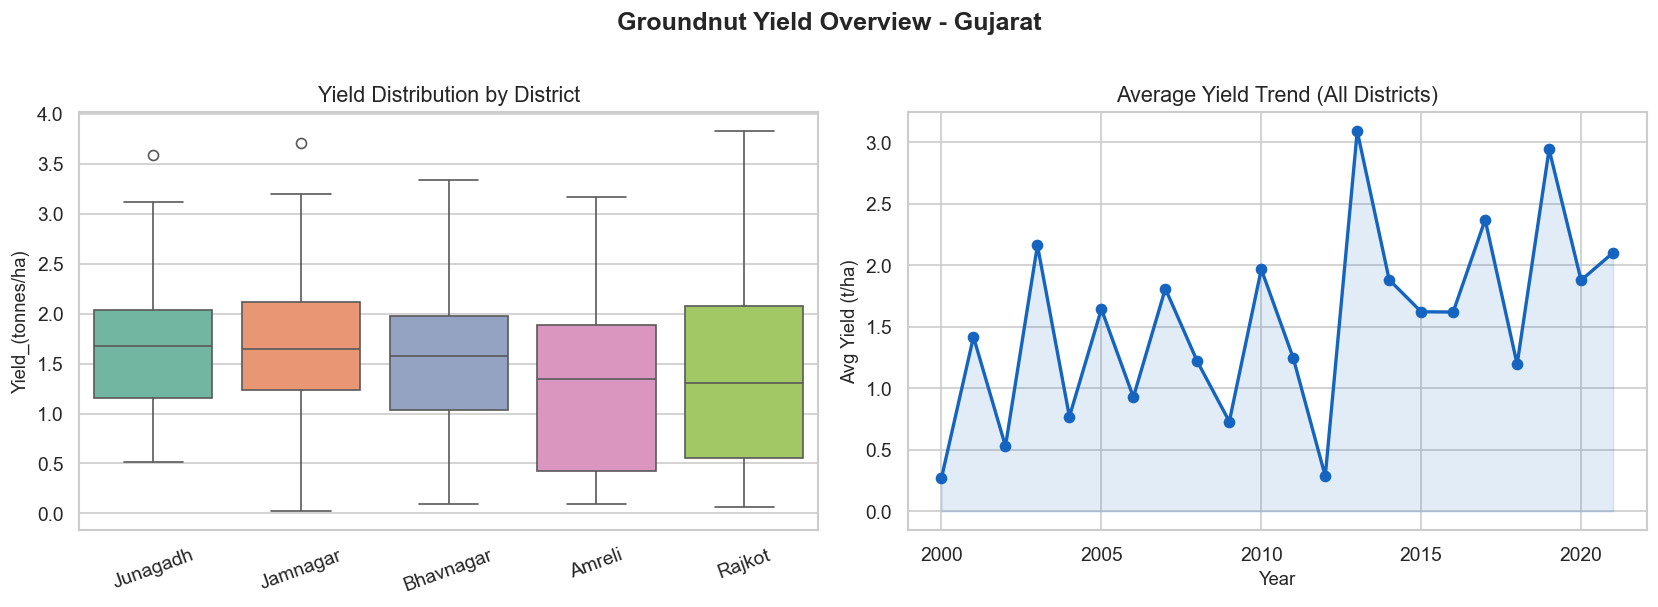

In [20]:
# ── 3a  Yield by district and over time ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = (df_clean.groupby("District")["Yield_(tonnes/ha)"]
         .median().sort_values(ascending=False).index)
sns.boxplot(data=df_clean, x="District", y="Yield_(tonnes/ha)",
            order=order, palette="Set2", ax=axes[0])
axes[0].set(title="Yield Distribution by District", xlabel="")
axes[0].tick_params(axis="x", rotation=20)

avg = df_clean.groupby("Year")["Yield_(tonnes/ha)"].mean()
axes[1].plot(avg.index, avg.values, marker="o", lw=2, color="#1565C0")
axes[1].fill_between(avg.index, avg.values, alpha=0.12, color="#1565C0")
axes[1].set(title="Average Yield Trend (All Districts)",
            xlabel="Year", ylabel="Avg Yield (t/ha)")

plt.suptitle("Groundnut Yield Overview - Gujarat", fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

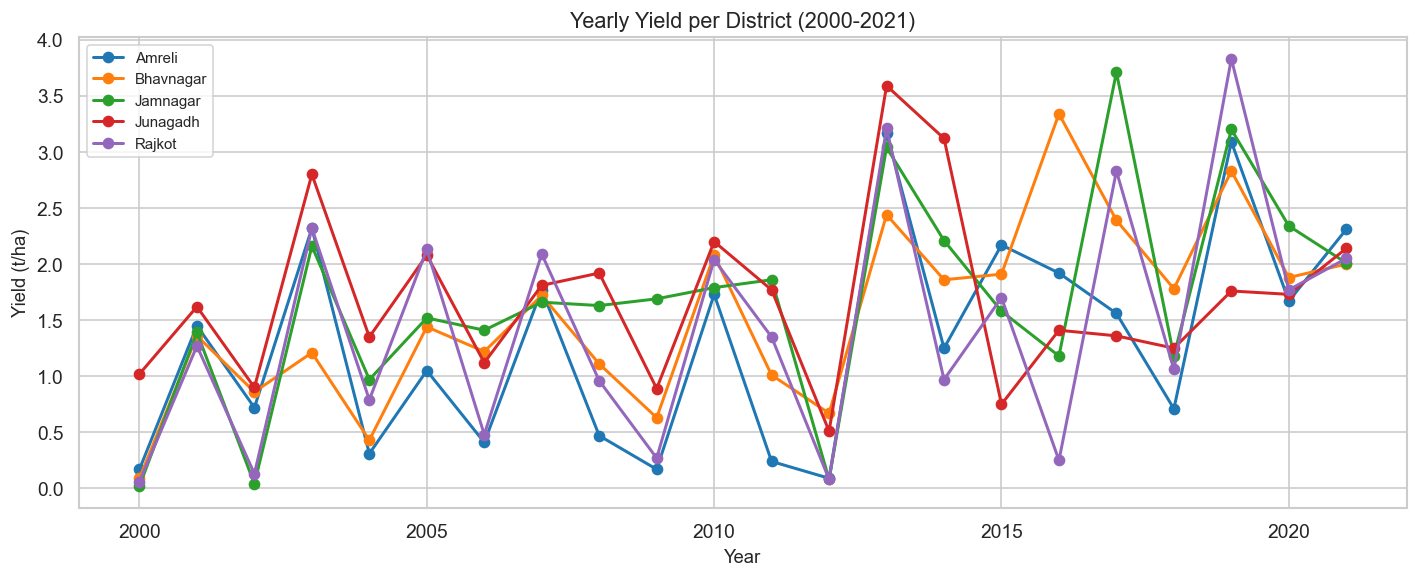

In [22]:
# ── 3b  Per-district yield over time ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
cmap = plt.cm.tab10
for i, (district, grp) in enumerate(df_clean.groupby("District")):
    g = grp.sort_values("Year")
    ax.plot(g["Year"], g["Yield_(tonnes/ha)"], marker="o",
            lw=1.8, label=district, color=cmap(i))

ax.set(title="Yearly Yield per District (2000-2021)",
       xlabel="Year", ylabel="Yield (t/ha)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout(); plt.show()

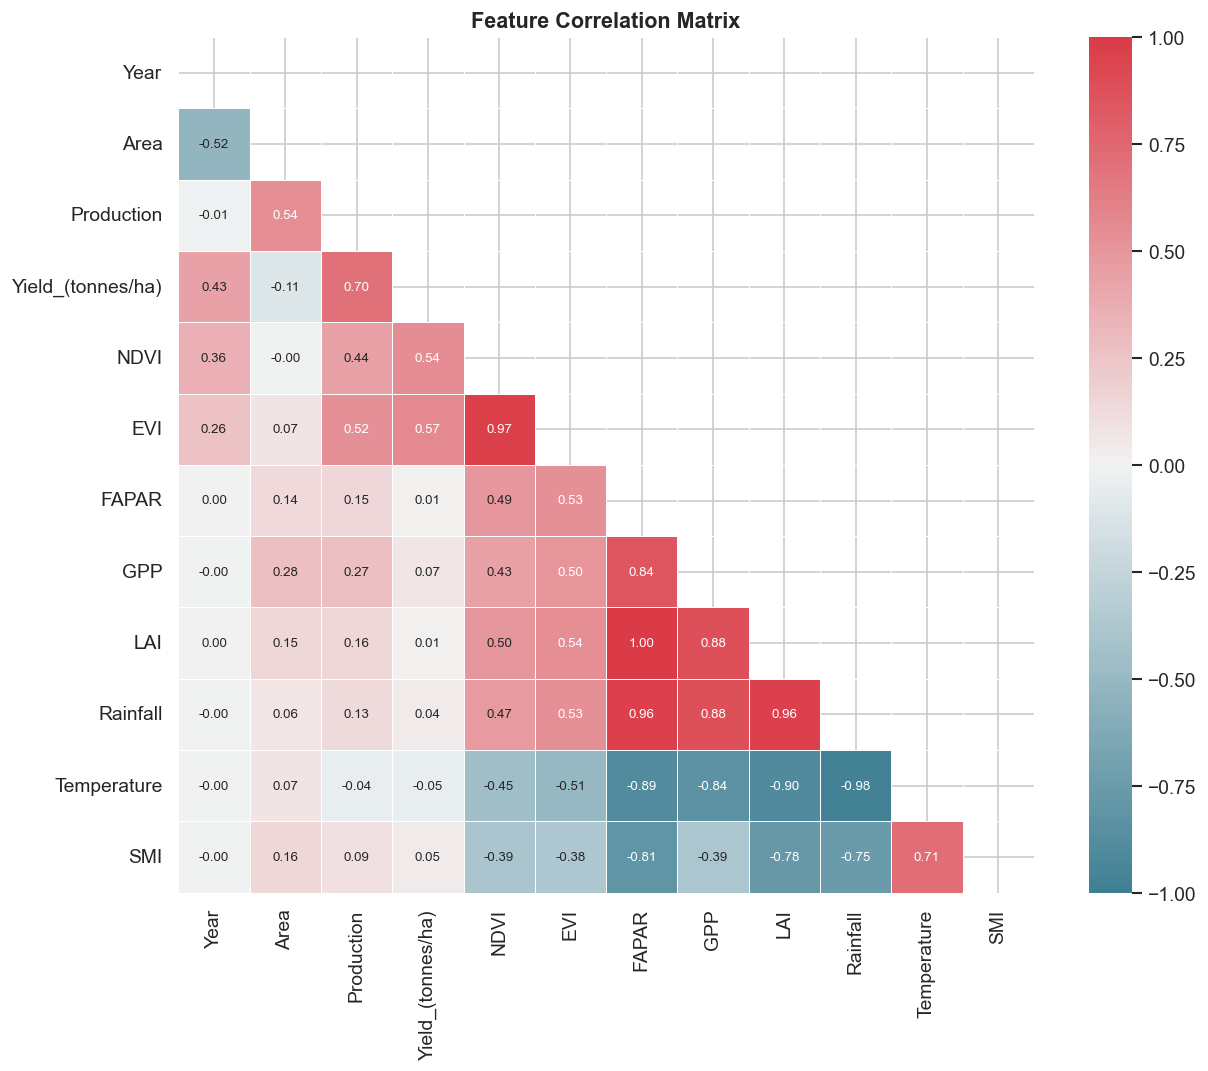

In [23]:
# ── 3c  Correlation heatmap ────────────────────────────────────────────────
num_cols = df_clean.select_dtypes("number").columns.drop("District_enc", errors="ignore")
corr = df_clean[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(220, 10, as_cmap=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=1, vmin=-1, center=0,
            annot=True, fmt=".2f", square=True, linewidths=0.5,
            annot_kws={"size": 8}, ax=ax)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
plt.tight_layout(); plt.show()

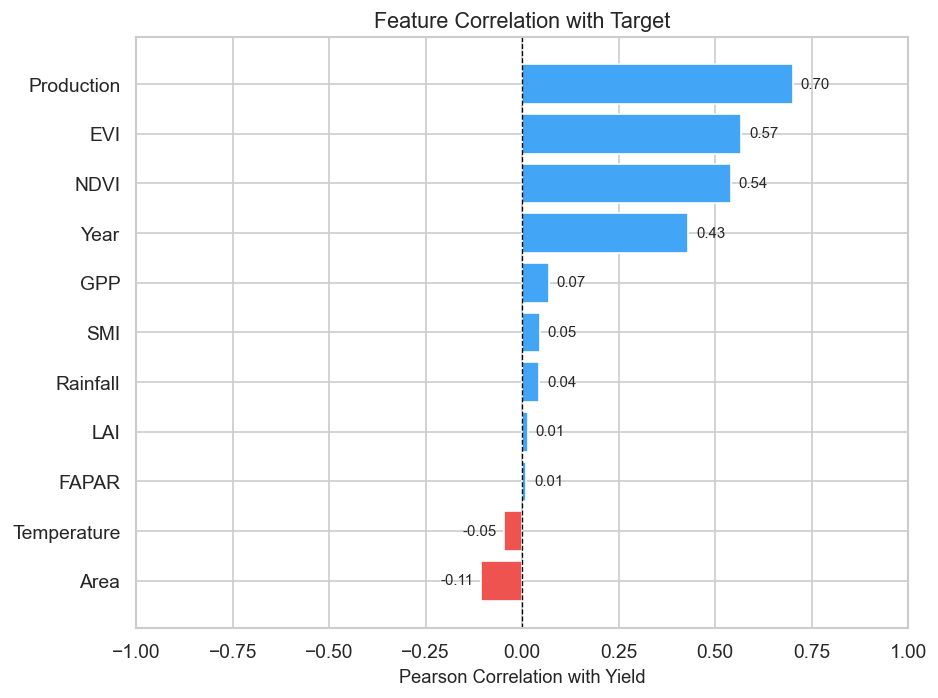

In [24]:
# ── 3d  Feature correlations with target (sorted bar) ─────────────────────
target_corr = corr["Yield_(tonnes/ha)"].drop("Yield_(tonnes/ha)").sort_values()
colors = ["#EF5350" if v < 0 else "#42A5F5" for v in target_corr]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", lw=0.8, ls="--")
ax.set(xlabel="Pearson Correlation with Yield",
       title="Feature Correlation with Target", xlim=(-1, 1))
for bar, v in zip(bars, target_corr.values):
    xpos = v + 0.02 if v >= 0 else v - 0.02
    ha   = "left"   if v >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f"{v:.2f}", va="center", ha=ha, fontsize=9)
plt.tight_layout(); plt.show()

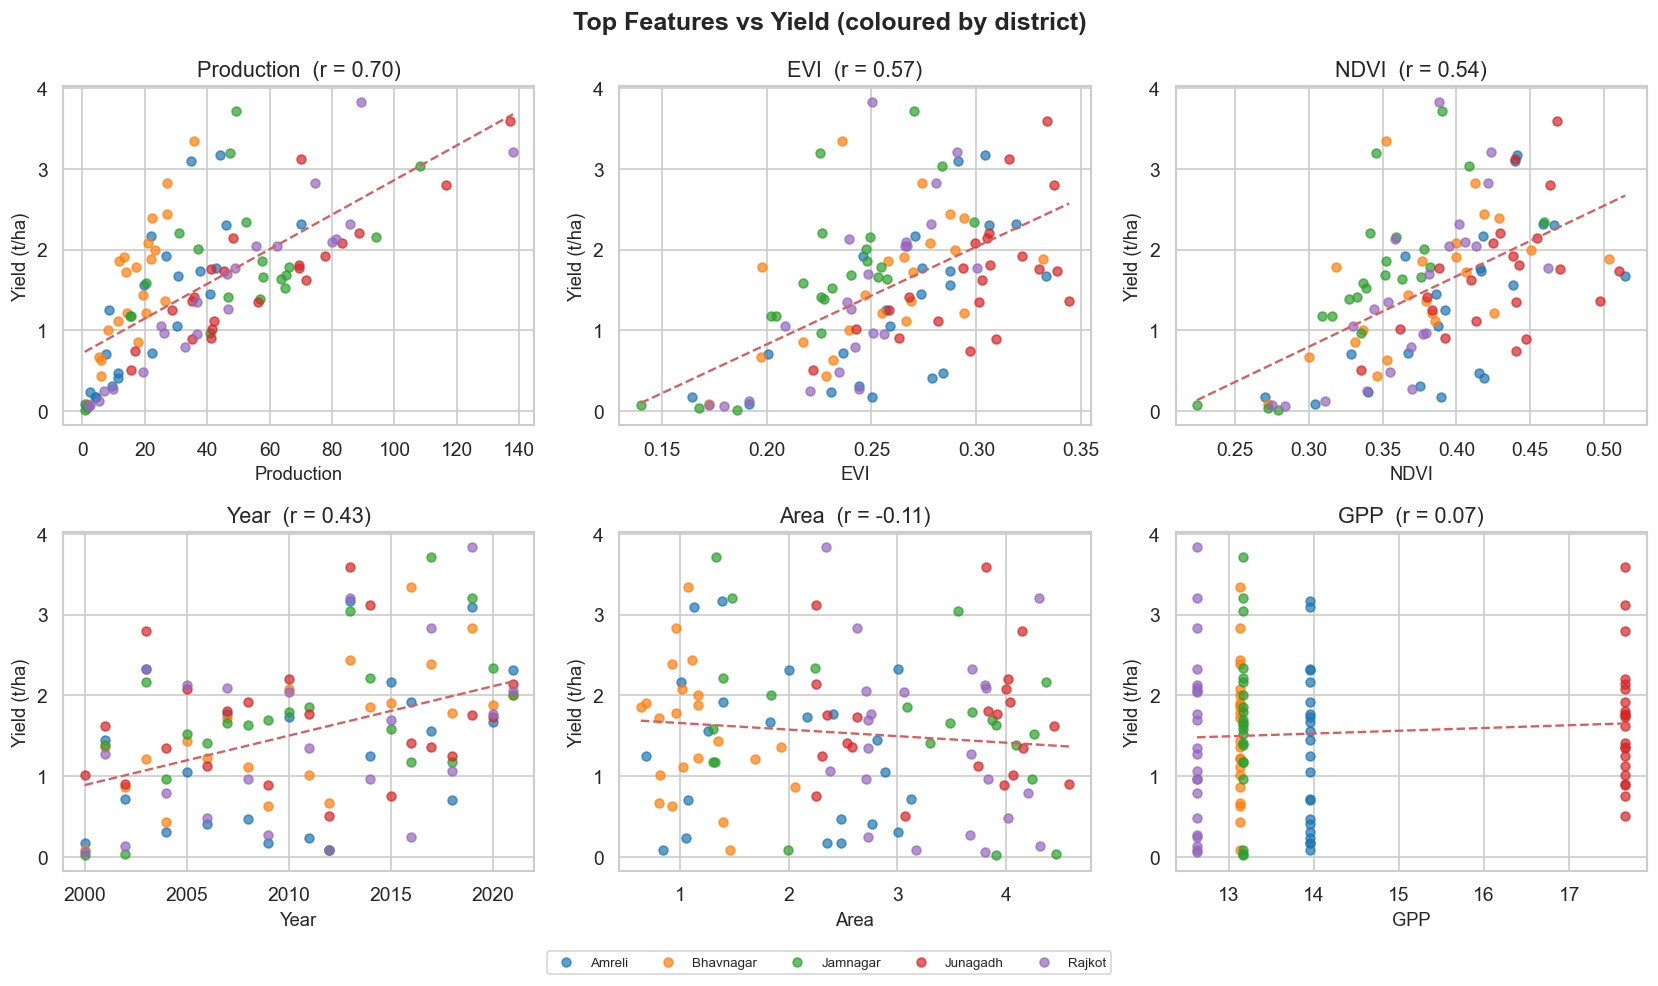

In [25]:
# ── 3e  Scatter: top 6 features vs yield ──────────────────────────────────
top6 = target_corr.abs().sort_values(ascending=False).head(6).index.tolist()
palette = plt.cm.tab10

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flatten(), top6):
    for j, (dist, grp) in enumerate(df_clean.groupby("District")):
        ax.scatter(grp[feat], grp["Yield_(tonnes/ha)"],
                   alpha=0.7, s=28, color=palette(j), label=dist)
    # trend line
    x = df_clean[feat].values
    y = df_clean["Yield_(tonnes/ha)"].values
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m*xr + b, "r--", lw=1.4)
    r = np.corrcoef(x, y)[0, 1]
    ax.set(xlabel=feat, ylabel="Yield (t/ha)",
           title=f"{feat}  (r = {r:.2f})")

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=6,
           fontsize=8, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Top Features vs Yield (coloured by district)",
             fontweight="bold")
plt.tight_layout(); plt.show()

## Section 4 - Feature Engineering

Seven domain-informed features derived from raw inputs to capture
agro-meteorological interactions that a model can exploit.

In [26]:
df_feat = df_clean.copy()

# 1  Vegetation Health Index — average of NDVI & EVI
df_feat["VHI"]              = (df_feat["NDVI"] + df_feat["EVI"]) / 2

# 2  Canopy Efficiency — GPP per unit leaf area
df_feat["Canopy_Eff"]       = df_feat["GPP"] / (df_feat["LAI"] + 1e-9)

# 3  Rainfall–Temperature ratio (crop water-heat balance)
df_feat["Rain_Temp_ratio"]  = df_feat["Rainfall"] / (df_feat["Temperature"] + 1e-9)

# 4  NDVI x FAPAR (vegetation cover × photosynthetic interception)
df_feat["NDVI_x_FAPAR"]     = df_feat["NDVI"] * df_feat["FAPAR"]

# 5  Soil Moisture × Rainfall (compound moisture stress)
df_feat["SMI_x_Rain"]       = df_feat["SMI"] * df_feat["Rainfall"]

# 6  EVI/NDVI ratio (canopy structural complexity)
df_feat["EVI_NDVI_ratio"]   = df_feat["EVI"] / (df_feat["NDVI"] + 1e-9)

# 7  Normalised year (temporal trend without raw year leakage)
yr_min, yr_max = df_feat["Year"].min(), df_feat["Year"].max()
df_feat["Year_Norm"]        = (df_feat["Year"] - yr_min) / (yr_max - yr_min)

ENG = ["VHI","Canopy_Eff","Rain_Temp_ratio",
       "NDVI_x_FAPAR","SMI_x_Rain","EVI_NDVI_ratio","Year_Norm"]

eng_corr = (df_feat[ENG + ["Yield_(tonnes/ha)"]].corr()
            ["Yield_(tonnes/ha)"].drop("Yield_(tonnes/ha)")
            .sort_values(ascending=False))
print("Engineered-feature correlations with Yield:")
print(eng_corr.to_string())

Engineered-feature correlations with Yield:
VHI                0.555793
Year_Norm          0.430776
EVI_NDVI_ratio     0.402774
NDVI_x_FAPAR       0.388312
Canopy_Eff         0.112316
SMI_x_Rain         0.082975
Rain_Temp_ratio    0.046693


## Section 5 - Preprocessing & Train/Test Split

In [27]:
FEATURES = [
    # Raw
    "Area", "Production", "NDVI", "EVI", "FAPAR",
    "GPP", "LAI", "Rainfall", "Temperature", "SMI",
    "District_enc", "Year",
    # Engineered
    "VHI", "Canopy_Eff", "Rain_Temp_ratio",
    "NDVI_x_FAPAR", "SMI_x_Rain", "EVI_NDVI_ratio", "Year_Norm",
]
TARGET = "Yield_(tonnes/ha)"

X = df_feat[FEATURES]
y = df_feat[TARGET]

# Temporal split: 2020-2021 as hold-out test (realistic evaluation)
test_mask      = df_feat["Year"] >= 2020
X_train, X_test = X[~test_mask], X[test_mask]
y_train, y_test = y[~test_mask], y[test_mask]

# Scale (fit on train only → no leakage)
scaler       = StandardScaler()
X_train_sc   = scaler.fit_transform(X_train)
X_test_sc    = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples | {y_train.min():.2f} – {y_train.max():.2f} t/ha")
print(f"Test : {X_test.shape[0]}  samples | {y_test.min():.2f} – {y_test.max():.2f} t/ha")
print(f"Features: {len(FEATURES)}")

Train: 100 samples | 0.02 – 3.83 t/ha
Test : 10  samples | 1.67 – 2.34 t/ha
Features: 19


## Section 6 - Model Training & 5-Fold Cross-Validation

All models evaluated under identical 5-Fold CV conditions.
Linear/distance models use scaled data; tree-based models use raw data.

In [28]:
NEEDS_SCALE = {"Linear Regression","Ridge","Lasso","ElasticNet","KNN","SVR"}

models = {
    "Linear Regression" : LinearRegression(),
    "Ridge"             : Ridge(alpha=1.0, random_state=SEED),
    "Lasso"             : Lasso(alpha=0.01, max_iter=10000, random_state=SEED),
    "ElasticNet"        : ElasticNet(alpha=0.01, l1_ratio=0.5,
                                     max_iter=10000, random_state=SEED),
    "KNN"               : KNeighborsRegressor(n_neighbors=5),
    "Decision Tree"     : DecisionTreeRegressor(max_depth=6, random_state=SEED),
    "Bagging"           : BaggingRegressor(n_estimators=100, random_state=SEED,
                                           n_jobs=-1),
    "Random Forest"     : RandomForestRegressor(n_estimators=200, random_state=SEED,
                                                n_jobs=-1),
    "Extra Trees"       : ExtraTreesRegressor(n_estimators=200, random_state=SEED,
                                              n_jobs=-1),
    "Gradient Boosting" : GradientBoostingRegressor(n_estimators=200,
                                                    learning_rate=0.1,
                                                    random_state=SEED),
    "AdaBoost"          : AdaBoostRegressor(n_estimators=100, random_state=SEED),
    "XGBoost"           : XGBRegressor(n_estimators=200, learning_rate=0.05,
                                       max_depth=5, subsample=0.8,
                                       colsample_bytree=0.8,
                                       random_state=SEED, verbosity=0),
    "SVR"               : SVR(kernel="rbf", C=100, epsilon=0.1),
}
if HAS_LGBM:
    models["LightGBM"] = LGBMRegressor(n_estimators=200, learning_rate=0.05,
                                        max_depth=5, random_state=SEED, verbose=-1)
if HAS_CATBOOST:
    models["CatBoost"] = CatBoostRegressor(iterations=200, learning_rate=0.05,
                                            depth=5, random_seed=SEED, verbose=0)

print(f"{len(models)} models registered.")

15 models registered.


In [29]:
kf      = KFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = ["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"]
cv_rows = []

for name, model in models.items():
    X_cv = X_train_sc if name in NEEDS_SCALE else X_train
    res  = cross_validate(model, X_cv, y_train, cv=kf,
                          scoring=scoring, return_train_score=True, n_jobs=-1)
    row  = {
        "Model"        : name,
        "CV R2 mean"   : res["test_r2"].mean(),
        "CV R2 std"    : res["test_r2"].std(),
        "CV MAE"       : -res["test_neg_mean_absolute_error"].mean(),
        "CV RMSE"      : -res["test_neg_root_mean_squared_error"].mean(),
        "Train R2"     : res["train_r2"].mean(),
    }
    cv_rows.append(row)
    print(f"  {name:<22}  R2={row['CV R2 mean']:+.4f}  "
          f"RMSE={row['CV RMSE']:.4f}  MAE={row['CV MAE']:.4f}")

cv_df = (pd.DataFrame(cv_rows)
           .sort_values("CV R2 mean", ascending=False)
           .reset_index(drop=True))
print("\nCross-validation complete.")

  Linear Regression       R2=+0.7792  RMSE=0.4111  MAE=0.3146
  Ridge                   R2=+0.7967  RMSE=0.3986  MAE=0.3072
  Lasso                   R2=+0.8065  RMSE=0.3898  MAE=0.2984
  ElasticNet              R2=+0.8006  RMSE=0.3951  MAE=0.3037
  KNN                     R2=+0.3910  RMSE=0.6923  MAE=0.5503
  Decision Tree           R2=+0.7200  RMSE=0.4364  MAE=0.3244
  Bagging                 R2=+0.8414  RMSE=0.3559  MAE=0.2672
  Random Forest           R2=+0.8420  RMSE=0.3549  MAE=0.2652
  Extra Trees             R2=+0.8563  RMSE=0.3382  MAE=0.2518
  Gradient Boosting       R2=+0.8854  RMSE=0.2987  MAE=0.2119
  AdaBoost                R2=+0.7684  RMSE=0.4155  MAE=0.3359
  XGBoost                 R2=+0.8849  RMSE=0.3021  MAE=0.2296
  SVR                     R2=+0.8661  RMSE=0.3167  MAE=0.2405
  LightGBM                R2=+0.8023  RMSE=0.3927  MAE=0.3093
  CatBoost                R2=+0.8260  RMSE=0.3705  MAE=0.2729

Cross-validation complete.


In [30]:
# ── Styled results table ───────────────────────────────────────────────────
display(
    cv_df.style
    .background_gradient(subset=["CV R2 mean"], cmap="Greens")
    .background_gradient(subset=["CV RMSE","CV MAE"], cmap="Reds_r")
    .format({"CV R2 mean":"{:.4f}","CV R2 std":"{:.4f}",
             "CV MAE":"{:.4f}","CV RMSE":"{:.4f}","Train R2":"{:.4f}"})
    .bar(subset=["CV R2 mean"], color="#A5D6A7")
)

,Model,CV R2 mean,CV R2 std,CV MAE,CV RMSE,Train R2
0,Gradient Boosting,0.8854,0.0240,0.2119,0.2987,1.0000
1,XGBoost,0.8849,0.0164,0.2296,0.3021,0.9999
2,SVR,0.8661,0.0428,0.2405,0.3167,0.9914
3,Extra Trees,0.8563,0.0381,0.2518,0.3382,1.0000
4,Random Forest,0.8420,0.0400,0.2652,0.3549,0.9742
5,Bagging,0.8414,0.0363,0.2672,0.3559,0.9753
6,CatBoost,0.8260,0.0545,0.2729,0.3705,0.9941
7,Lasso,0.8065,0.0267,0.2984,0.3898,0.8539
8,LightGBM,0.8023,0.0279,0.3093,0.3927,0.9207
9,ElasticNet,0.8006,0.0252,0.3037,0.3951,0.8559


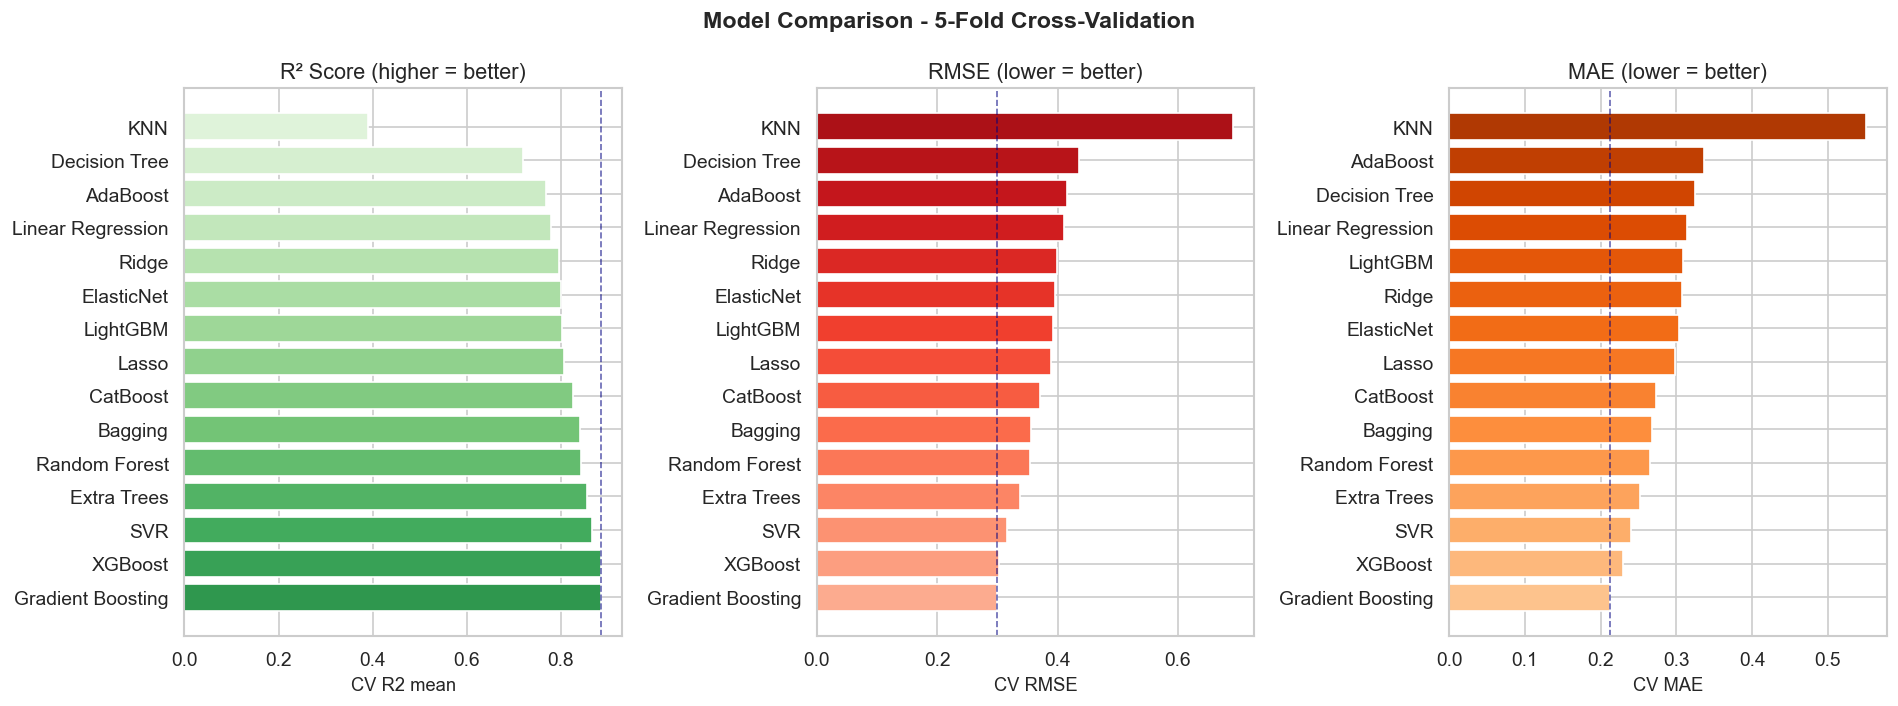

In [48]:
# ── Model comparison chart ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
metrics_plot = [
    ("CV R2 mean",  "Greens_r", "R² Score (higher = better)"),
    ("CV RMSE",     "Reds",     "RMSE (lower = better)"),
    ("CV MAE",      "Oranges",  "MAE (lower = better)"),
]
for ax, (col, cmap, title) in zip(axes, metrics_plot):
    asc = col != "CV R2 mean"
    sdf = cv_df.sort_values(col, ascending=asc)
    n   = len(sdf)
    c   = plt.cm.get_cmap(cmap)(np.linspace(0.3, 0.85, n))
    ax.barh(sdf["Model"], sdf[col], color=c, edgecolor="white")
    bv  = sdf[col].max() if not asc else sdf[col].min()
    ax.axvline(bv, color="navy", ls="--", lw=1, alpha=0.6)
    ax.set(title=title, xlabel=col)

plt.suptitle("Model Comparison - 5-Fold Cross-Validation",
             fontweight="bold", fontsize=14)
plt.tight_layout(); plt.show()

## Section 7 - Best Model: Test Set Evaluation

In [32]:
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-8))) * 100
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MAPE%": mape}

best_name  = cv_df.iloc[0]["Model"]
best_model = models[best_name]
print(f"Best model by CV R2: {best_name}")

X_tr = X_train_sc if best_name in NEEDS_SCALE else X_train
X_te = X_test_sc  if best_name in NEEDS_SCALE else X_test

best_model.fit(X_tr, y_train)
yhat_tr = best_model.predict(X_tr)
yhat_te = best_model.predict(X_te)

m_train = metrics(y_train, yhat_tr)
m_test  = metrics(y_test,  yhat_te)

perf = pd.DataFrame([m_train, m_test], index=["Train", "Test"])
display(perf.style.background_gradient(cmap="Blues").format("{:.4f}"))

Best model by CV R2: Gradient Boosting


,R2,RMSE,MAE,MAPE%
Train,0.9999,0.0070,0.0058,1.0697
Test,-3.5126,0.4664,0.3974,19.9148


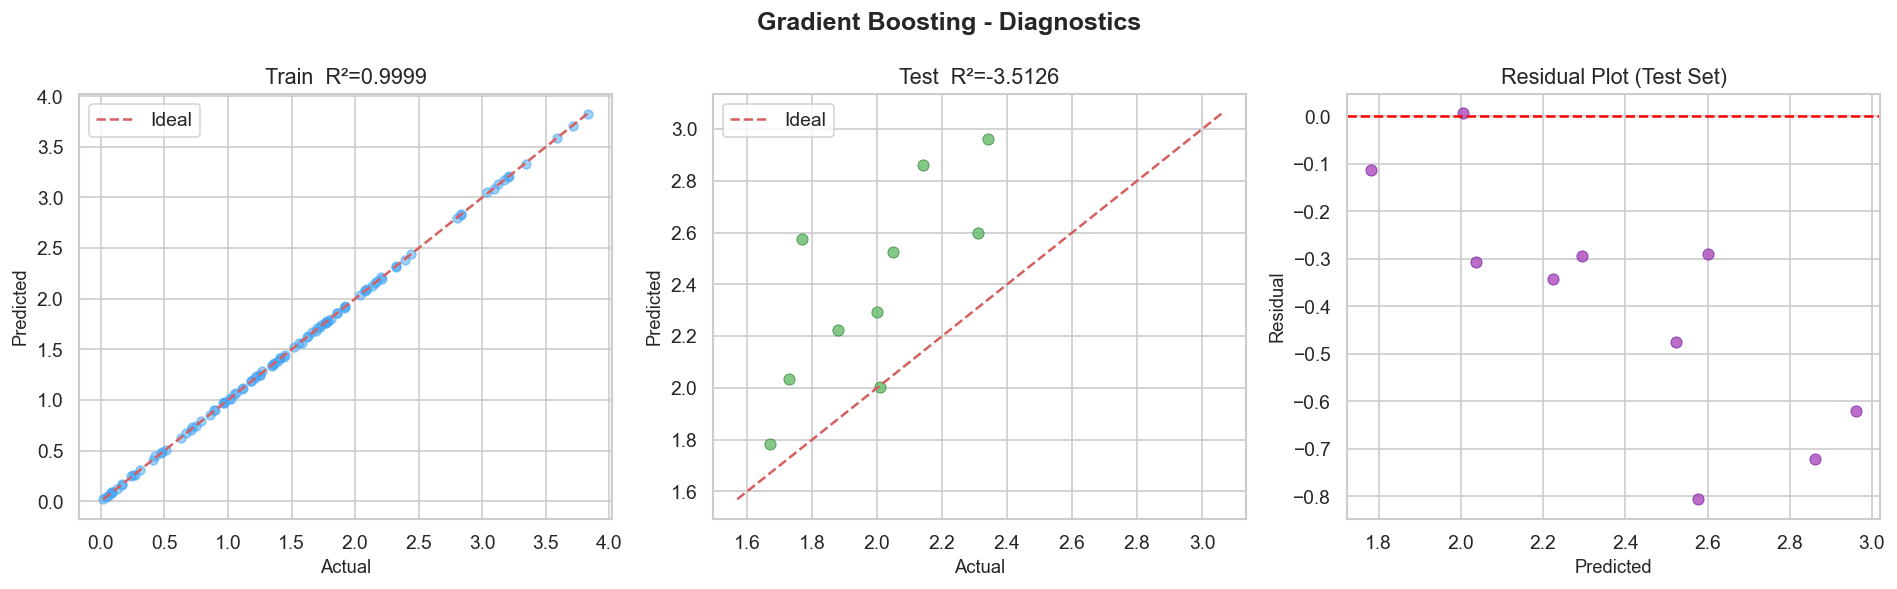

In [47]:
# ── Diagnostic plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# A) Train: actual vs predicted
ax = axes[0]
ax.scatter(y_train, yhat_tr, alpha=0.5, s=28, color="#42A5F5")
lim = [min(y_train.min(), yhat_tr.min()), max(y_train.max(), yhat_tr.max())]
ax.plot(lim, lim, "r--", lw=1.5, label="Ideal")
ax.set(xlabel="Actual", ylabel="Predicted",
       title=f"Train  R²={m_train['R2']:.4f}")
ax.legend()

# B) Test: actual vs predicted
ax = axes[1]
ax.scatter(y_test, yhat_te, alpha=0.8, s=45,
           color="#66BB6A", edgecolors="#2E7D32", lw=0.5)
lim = [min(y_test.min(), yhat_te.min())-0.1,
       max(y_test.max(), yhat_te.max())+0.1]
ax.plot(lim, lim, "r--", lw=1.5, label="Ideal")
ax.set(xlabel="Actual", ylabel="Predicted",
       title=f"Test  R²={m_test['R2']:.4f}")
ax.legend()

# C) Residuals
ax = axes[2]
res = y_test.values - yhat_te
ax.scatter(yhat_te, res, alpha=0.8, s=45,
           color="#AB47BC", edgecolors="#6A1B9A", lw=0.5)
ax.axhline(0, color="red", ls="--", lw=1.5)
ax.set(xlabel="Predicted", ylabel="Residual",
       title="Residual Plot (Test Set)")

plt.suptitle(f"{best_name} - Diagnostics", fontweight="bold")
plt.tight_layout(); plt.show()

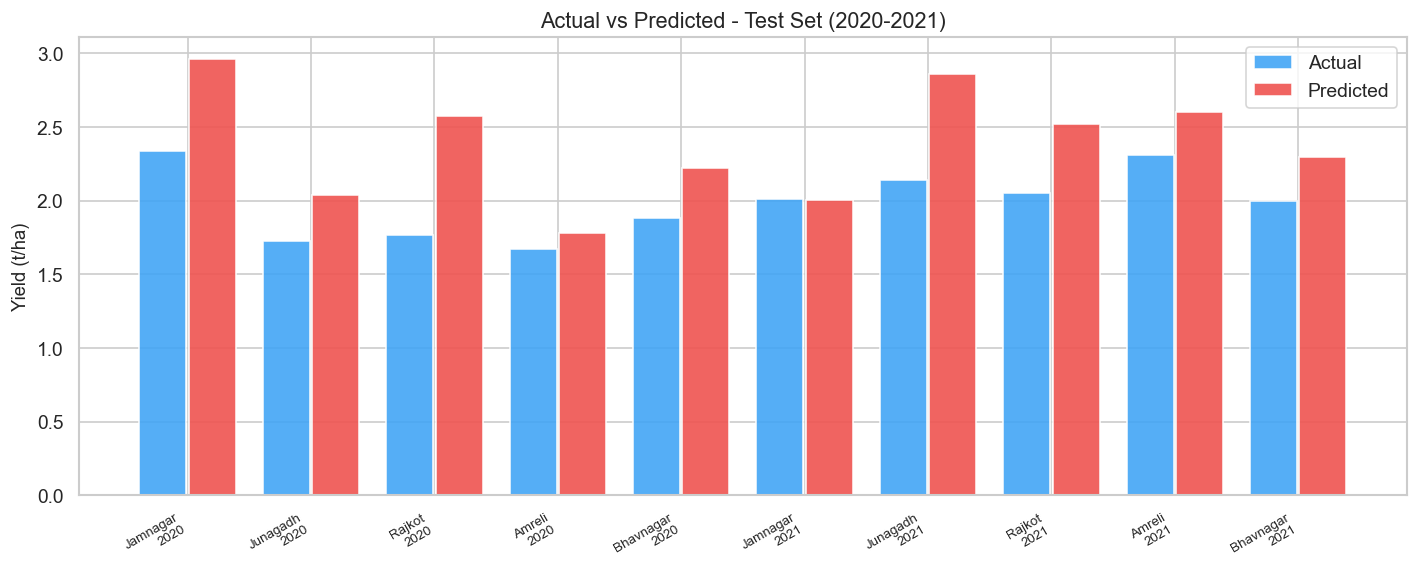

In [46]:
# ── Bar chart: actual vs predicted by district/year ────────────────────────
test_df             = df_feat[test_mask].copy()
test_df["Predicted"] = yhat_te
labels = [f"{r['District']}\n{int(r['Year'])}"
          for _, r in test_df.iterrows()]
x = np.arange(len(test_df))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, test_df["Yield_(tonnes/ha)"], width=0.38,
       label="Actual",    color="#42A5F5", alpha=0.9)
ax.bar(x + 0.2, test_df["Predicted"],          width=0.38,
       label="Predicted", color="#EF5350", alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8, rotation=30, ha="right")
ax.set(ylabel="Yield (t/ha)",
       title="Actual vs Predicted - Test Set (2020-2021)")
ax.legend()
plt.tight_layout(); plt.show()

## Section 8 - Hyperparameter Tuning (XGBoost)

In [35]:
xgb_base = XGBRegressor(random_state=SEED, verbosity=0, n_jobs=-1)

param_dist = {
    "n_estimators"    : [100, 200, 300, 500],
    "max_depth"       : [3, 4, 5, 6, 7],
    "learning_rate"   : [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    "subsample"       : [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 5],
    "gamma"           : [0, 0.05, 0.1, 0.2, 0.3],
    "reg_alpha"       : [0, 0.01, 0.05, 0.1, 1.0],
    "reg_lambda"      : [0.5, 1.0, 1.5, 2.0],
}

rscv = RandomizedSearchCV(
    xgb_base, param_dist,
    n_iter=60, cv=5, scoring="r2",
    random_state=SEED, n_jobs=-1, verbose=0,
)
rscv.fit(X_train, y_train)

print("Best parameters:")
for k, v in sorted(rscv.best_params_.items()):
    print(f"  {k:<22}: {v}")
print(f"\nBest CV R2 : {rscv.best_score_:.4f}")

Best parameters:
  colsample_bytree      : 1.0
  gamma                 : 0
  learning_rate         : 0.08
  max_depth             : 6
  min_child_weight      : 3
  n_estimators          : 500
  reg_alpha             : 0
  reg_lambda            : 1.5
  subsample             : 0.9

Best CV R2 : 0.8688


In [36]:
tuned = rscv.best_estimator_
yhat_tuned_tr = tuned.predict(X_train)
yhat_tuned_te = tuned.predict(X_test)

m_tuned_train = metrics(y_train, yhat_tuned_tr)
m_tuned_test  = metrics(y_test,  yhat_tuned_te)

tuned_perf = pd.DataFrame([m_tuned_train, m_tuned_test], index=["Train", "Test"])
print("Tuned XGBoost performance:")
display(tuned_perf.style.background_gradient(cmap="Greens").format("{:.4f}"))

print(f"\nTest R2 improvement: {m_tuned_test['R2'] - m_test['R2']:+.4f}")

Tuned XGBoost performance:


,R2,RMSE,MAE,MAPE%
Train,1.0000,0.0007,0.0005,0.1270
Test,-5.5436,0.5616,0.4353,21.5345



Test R2 improvement: -2.0310


## Section 9 - Feature Importance & Explainability

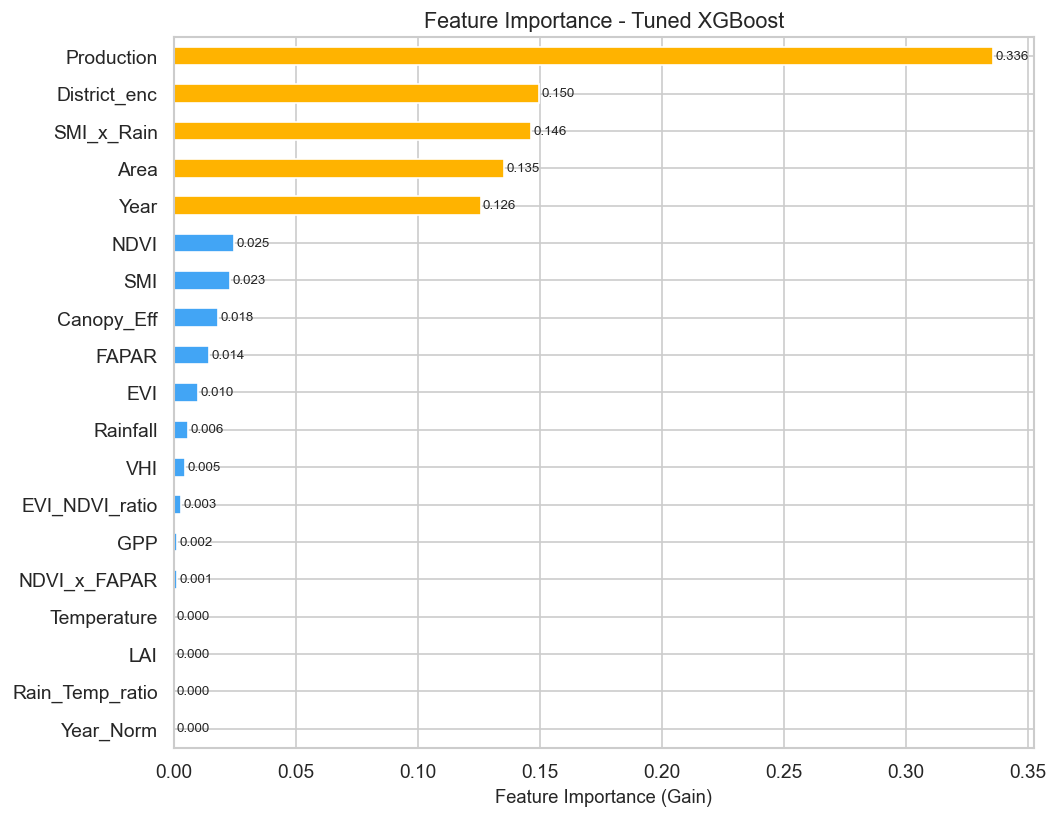

Top 5 features:
  Production              0.3358
  District_enc            0.1499
  SMI_x_Rain              0.1464
  Area                    0.1352
  Year                    0.1258


In [44]:
# ── XGBoost built-in importance (F-gain) ───────────────────────────────────
imp = pd.Series(tuned.feature_importances_, index=FEATURES).sort_values()
colors = ["#FFB300" if i >= len(imp)-5 else "#42A5F5" for i in range(len(imp))]

fig, ax = plt.subplots(figsize=(9, 7))
imp.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set(xlabel="Feature Importance (Gain)",
       title="Feature Importance - Tuned XGBoost")
for i, v in enumerate(imp.values):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout(); plt.show()

print("Top 5 features:")
for feat, val in imp.sort_values(ascending=False).head(5).items():
    print(f"  {feat:<22}  {val:.4f}")

In [38]:
# ── SHAP explainability ────────────────────────────────────────────────────
if HAS_SHAP:
    explainer   = shap.TreeExplainer(tuned)
    shap_values = explainer.shap_values(X_train)

    print("SHAP Bar Summary (mean |SHAP| per feature):")
    shap.summary_plot(shap_values, X_train, feature_names=FEATURES,
                      plot_type="bar", show=True, max_display=15)

    print("\nSHAP Beeswarm — feature value vs impact on prediction:")
    shap.summary_plot(shap_values, X_train, feature_names=FEATURES,
                      show=True, max_display=15)
else:
    print("SHAP not installed. Run: !pip install shap")

SHAP not installed. Run: !pip install shap


## Section 10 - Final Leaderboard

In [43]:
final_rows = []
for name, model in models.items():
    Xtr = X_train_sc if name in NEEDS_SCALE else X_train
    Xte = X_test_sc  if name in NEEDS_SCALE else X_test
    model.fit(Xtr, y_train)
    m = metrics(y_test, model.predict(Xte))
    m["Model"] = name
    final_rows.append(m)

# Add tuned XGBoost
m = metrics(y_test, yhat_tuned_te)
m["Model"] = "XGBoost (Tuned) [BEST]"
final_rows.append(m)

final_df = (pd.DataFrame(final_rows)[["Model","R2","RMSE","MAE","MAPE%"]]
              .sort_values("R2", ascending=False)
              .reset_index(drop=True))

print("=" * 65)
print("  FINAL LEADERBOARD - TEST SET (2020-2021)")
print("=" * 65)
display(
    final_df.style
    .background_gradient(subset=["R2"],   cmap="Greens")
    .background_gradient(subset=["RMSE","MAE","MAPE%"], cmap="Reds_r")
    .format({"R2":"{:.4f}","RMSE":"{:.4f}","MAE":"{:.4f}","MAPE%":"{:.2f}"})
    .bar(subset=["R2"], color="#A5D6A7")
)

  FINAL LEADERBOARD - TEST SET (2020-2021)


,Model,R2,RMSE,MAE,MAPE%
0,Lasso,-1.4033,0.3403,0.2971,15.77
1,ElasticNet,-1.8504,0.3707,0.3289,17.40
2,Random Forest,-2.7205,0.4235,0.3959,20.26
3,Ridge,-2.7564,0.4255,0.3835,20.17
4,Linear Regression,-3.0922,0.4441,0.3800,19.67
5,Decision Tree,-3.3267,0.4567,0.3823,19.23
6,Gradient Boosting,-3.5126,0.4664,0.3974,19.91
7,XGBoost,-3.5184,0.4667,0.4003,20.02
8,Bagging,-3.6950,0.4757,0.4445,22.59
9,KNN,-3.8071,0.4814,0.4386,22.71


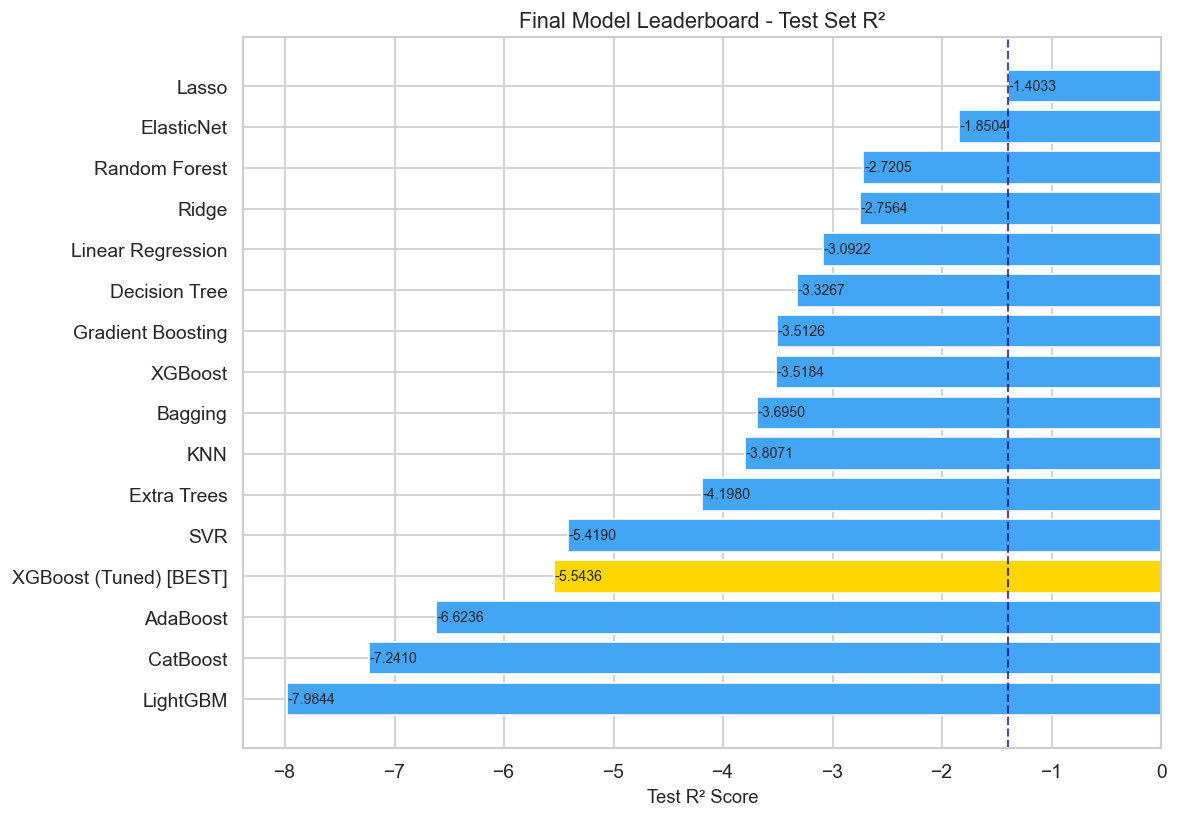


Winner : Lasso
  R2    : -1.4033
  RMSE  : 0.3403 t/ha
  MAE   : 0.2971 t/ha
  MAPE  : 15.77%


In [42]:
# ── Final comparison chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sdf    = final_df.sort_values("R2", ascending=True)
bar_c  = ["#FFD700" if "[BEST]" in m else "#42A5F5" for m in sdf["Model"]]
bars   = ax.barh(sdf["Model"], sdf["R2"], color=bar_c, edgecolor="white")
ax.axvline(sdf["R2"].max(), color="navy", ls="--", lw=1.3, alpha=0.7)
ax.set(xlabel="Test R² Score",
       title="Final Model Leaderboard - Test Set R²")
for bar, v in zip(bars, sdf["R2"]):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontsize=8.5)
plt.tight_layout(); plt.show()

winner = final_df.iloc[0]
print(f"\nWinner : {winner['Model']}")
print(f"  R2    : {winner['R2']:.4f}")
print(f"  RMSE  : {winner['RMSE']:.4f} t/ha")
print(f"  MAE   : {winner['MAE']:.4f} t/ha")
print(f"  MAPE  : {winner['MAPE%']:.2f}%")

In [41]:
# ── Save model & scaler ────────────────────────────────────────────────────
import joblib, os

out_dir = "/content/output"
os.makedirs(out_dir, exist_ok=True)

joblib.dump(tuned,  f"{out_dir}/groundnut_xgb_tuned.pkl")
joblib.dump(scaler, f"{out_dir}/groundnut_scaler.pkl")
final_df.to_csv(f"{out_dir}/model_leaderboard.csv", index=False)

print(f"Saved to {out_dir}/")
print("  groundnut_xgb_tuned.pkl")
print("  groundnut_scaler.pkl")
print("  model_leaderboard.csv")

OSError: [Errno 30] Read-only file system: '/content'